<a href="https://colab.research.google.com/github/WizardsugarGG/MINERIA-DE-DATOS/blob/main/k%20menas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

In [2]:
#crear un dataFrame

compras = [1, 2, 1.5, 10, 12, 11, 4, 5, 6]
gasto = [2, 3, 2.5, 9, 11, 10, 5, 6, 7]

df = pd.DataFrame({
    'Compras': compras,
    'Gasto': gasto
})

print("DataFrame:")
print(df)

DataFrame:
   Compras  Gasto
0      1.0    2.0
1      2.0    3.0
2      1.5    2.5
3     10.0    9.0
4     12.0   11.0
5     11.0   10.0
6      4.0    5.0
7      5.0    6.0
8      6.0    7.0


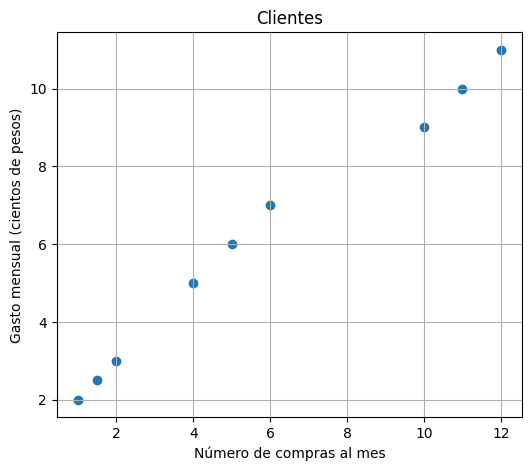

In [5]:
# 2. Graficar los puntos


plt.figure(figsize=(6,5))
plt.scatter(df['Compras'], df['Gasto'])
plt.xlabel('Número de compras al mes')
plt.ylabel('Gasto mensual (cientos de pesos)')
plt.title('Clientes')
plt.grid(True)
plt.show()

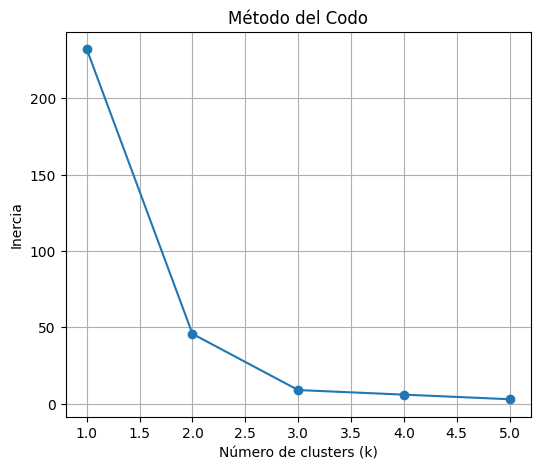

In [6]:
# 3. Método del codo para encontrar K


inercia = []

K = range(1, 6)

for k in K:
    modelo = KMeans(n_clusters=k, random_state=42, n_init=10)
    modelo.fit(df)
    inercia.append(modelo.inertia_)
# Graficar método del codo
plt.figure(figsize=(6,5))
plt.plot(K, inercia, marker='o')
plt.xlabel('Número de clusters (k)')
plt.ylabel('Inercia')
plt.title('Método del Codo')
plt.grid(True)
plt.show()

In [7]:
# 4. Aplicar K-Means
# ============================================

# Según el método del codo se puede usar k=3
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)

df['Cluster'] = kmeans.fit_predict(df)

print("\nDataFrame con clusters:")
print(df)


DataFrame con clusters:
   Compras  Gasto  Cluster
0      1.0    2.0        1
1      2.0    3.0        1
2      1.5    2.5        1
3     10.0    9.0        2
4     12.0   11.0        2
5     11.0   10.0        2
6      4.0    5.0        0
7      5.0    6.0        0
8      6.0    7.0        0


In [8]:
# 5. Mostrar centroides
# ============================================

centroides = kmeans.cluster_centers_

print("\nCentroides:")
print(centroides)


Centroides:
[[ 5.   6. ]
 [ 1.5  2.5]
 [11.  10. ]]


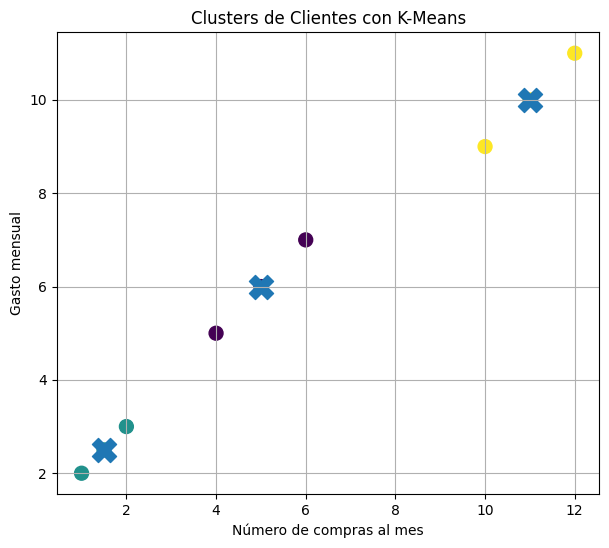

In [9]:
# 6. Graficar clusters y centroides
# ============================================

plt.figure(figsize=(7,6))

plt.scatter(
    df['Compras'],
    df['Gasto'],
    c=df['Cluster'],
    s=100
)
# Graficar centroides
plt.scatter(
    centroides[:,0],
    centroides[:,1],
    marker='X',
    s=300
)

plt.xlabel('Número de compras al mes')
plt.ylabel('Gasto mensual')
plt.title('Clusters de Clientes con K-Means')
plt.grid(True)

plt.show()

El algoritmo K-Means permitió segmentar a los clientes en:

Bajo consumo
Consumo medio
Alto consumo

Esto ayuda a las empresas a crear estrategias específicas para cada tipo de cliente, por ejemplo:

Ofertas para atraer clientes de bajo consumo
Programas de fidelización para clientes medios
Beneficios exclusivos para clientes premium


Ejercicio 2: Agrupamiento de personas según salud física
Objetivo: Identificar grupos de personas según su condición física.



In [10]:
# 1. Crear DataFrame
# ============================================

ejercicio = [0.5, 1, 1.5, 6, 7, 8, 2, 3, 4]
condicion = [2, 3, 2.5, 8, 9, 10, 4, 5, 6]

df = pd.DataFrame({
    'Ejercicio': ejercicio,
    'Condicion': condicion
})

print(df)

   Ejercicio  Condicion
0        0.5        2.0
1        1.0        3.0
2        1.5        2.5
3        6.0        8.0
4        7.0        9.0
5        8.0       10.0
6        2.0        4.0
7        3.0        5.0
8        4.0        6.0


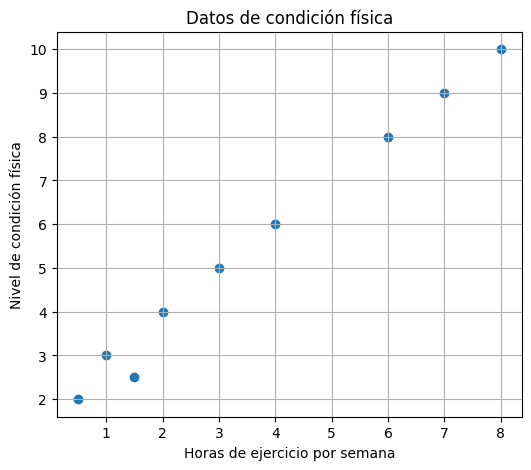

In [11]:
# 2. Visualizar datos
# ============================================

plt.figure(figsize=(6,5))
plt.scatter(df['Ejercicio'], df['Condicion'])
plt.xlabel('Horas de ejercicio por semana')
plt.ylabel('Nivel de condición física')
plt.title('Datos de condición física')
plt.grid(True)
plt.show()

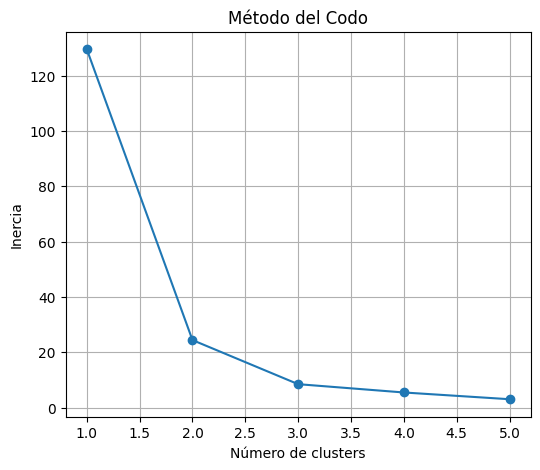

In [12]:
# 3. Método del codo
# ============================================

inercia = []

K = range(1,6)

for k in K:
    modelo = KMeans(n_clusters=k, random_state=42, n_init=10)
    modelo.fit(df)
    inercia.append(modelo.inertia_)

plt.figure(figsize=(6,5))
plt.plot(K, inercia, marker='o')
plt.xlabel('Número de clusters')
plt.ylabel('Inercia')
plt.title('Método del Codo')
plt.grid(True)
plt.show()

In [14]:
# 4. Aplicar K-Means
# ============================================

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)

df['Cluster'] = kmeans.fit_predict(df)

print("\nDataFrame con clusrters")
print(df)


DataFrame con clusrters
   Ejercicio  Condicion  Cluster
0        0.5        2.0        0
1        1.0        3.0        0
2        1.5        2.5        0
3        6.0        8.0        1
4        7.0        9.0        1
5        8.0       10.0        1
6        2.0        4.0        0
7        3.0        5.0        2
8        4.0        6.0        2


In [15]:
# 5. Obtener centroides
# ============================================

centroides = kmeans.cluster_centers_

print("\nCentroides:")
print(centroides)


Centroides:
[[1.25  2.875]
 [7.    9.   ]
 [3.5   5.5  ]]


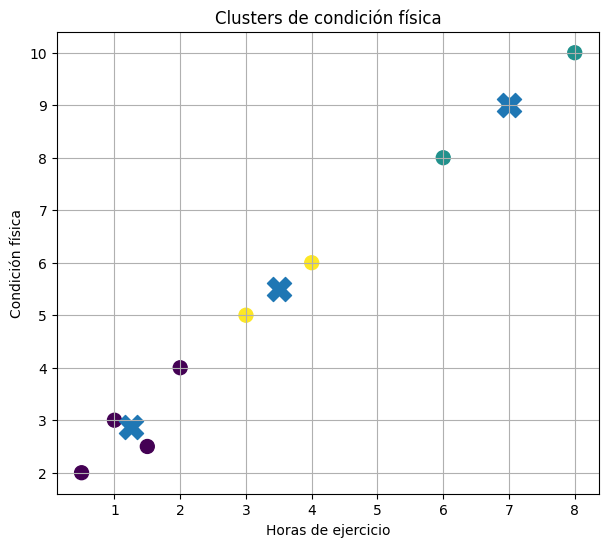

In [16]:
# 6. Graficar clusters
# ============================================

plt.figure(figsize=(7,6))

plt.scatter(
    df['Ejercicio'],
    df['Condicion'],
    c=df['Cluster'],
    s=100
)

# Centroides
plt.scatter(
    centroides[:,0],
    centroides[:,1],
    marker='X',
    s=300
)

plt.xlabel('Horas de ejercicio')
plt.ylabel('Condición física')
plt.title('Clusters de condición física')
plt.grid(True)

plt.show()

-grupo 1 : personas sedentarias
son personas con habitos poco activos y menor resistencia fisica

-grupo 2 : personas con actividad moderda

mantienen una actividad fisica regular y un estado de salud aceptable

-grupo 3 : personas muy activas
son personas deportistas o muy disciploinadas